# Lorenz-96 forcing ensemble

Loads a saved reduced-order model, integrates with it, and reproduces the three
figures for this case. No fitting is performed here.

The state is signed, z = x - F, so $\tau_\mathrm{split}$ is measured in
absolute terms and the positivity projection does not apply.


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath("../../../"))

import numpy as np
import matplotlib.pyplot as plt

from src import plots as P
from src.cluster import Cluster
from src.config import SUBSTEPS, combo_stem
from src.data import load_trajectories, open_feature_matrix
from src.evaluate import read_table
from src.pipeline import case_config, load_case_context, split_paths
from src.rom import EnsembleROM, fit_global_rom

%matplotlib inline
%load_ext autoreload
%autoreload 2

CASE = "lorenz96"
OUT_DIR = "."
GEN_DIR = "../../../datasets/lorenz96/N100_F0-2.5"

SWEEP_DIR = f"{OUT_DIR}/sweep"
FIG_DIR = f"{OUT_DIR}/figures"

QOI = [0, 25, 50, 75]
TOLS = (0.005, 0.02, 0.25)         # available: 0.005, 0.01, 0.02, 0.05, 0.25
TWIN_TOL = 0.02
MAX_CLUSTERS = 2048               # cap on the refined partition for this case
N_EVAL = {"test": 50, "train": 150}

TAU, ETA = 0.02, 1e-3             # the combination to integrate
GLOBAL_RANK = 91                  # basis size for the single-cluster baseline
F_TARGET = 2.45                   # forcing to display; the nearest available value is used

## Load the result tables


In [2]:
def load_split(split):
    return P.load_frames(OUT_DIR, eval_split=split)


sweep_te, rank_te, rho = load_split("test")
sweep_tr, rank_tr, _ = load_split("train")

qoi = [f"x{q}" for q in QOI]
etas = sorted(np.unique(sweep_te["eta"]), reverse=True)
print(f"{len(etas)} eta x {len(np.unique(sweep_te['tau_split']))} tau | "
      f"qoi={qoi} | rho={rho}")

  dropping rank [100] from the rank sweep: residual energy is 0 (full basis), which has no place on a log-eta axis
  dropping rank [100] from the rank sweep: residual energy is 0 (full basis), which has no place on a log-eta axis
8 eta x 5 tau | qoi=['x0', 'x25', 'x50', 'x75'] | rho=100


## Load one fit

`TAU` and `ETA` select the combination. The network comes from the context,
which also carries the forcing histories and the initial states.


In [3]:
stem = combo_stem(TAU, ETA)

cfg = case_config(CASE, OUT_DIR, gen_dir=GEN_DIR)
ctx = load_case_context(CASE, cfg)

cl = Cluster.load(f"{SWEEP_DIR}/cluster_{stem}.npz")
ens = EnsembleROM.load(f"{SWEEP_DIR}/ensemble_{stem}.npz", cl,
                       ctx.net).precompute_B_structure()

feat_path, tracers, ids = split_paths(ctx, "test")
print(f"{cl.n_clusters} clusters | mean basis size {ens.mean_rank():.2f} | "
      f"{len(ids)} test forcings | {ctx.n_steps} intervals")

  reuse shifted source: ../experiments/lorenz96/N100_F0-2.5/lorenz96_source.npy


<string>:29: RuntimeWarning: error_norm='absolute': rank proxy disabled, so the rank walk re-scores every rank from r0+1 and the build is slower.


  200 forcings, 513 knots, 512 steps, dt_hydro=0.0390625
  loaded split from ../experiments/lorenz96/N100_F0-2.5/feature_matrix_indices.npy, ../experiments/lorenz96/N100_F0-2.5/feature_matrix_test_indices.npy
train forcings: 150,  test forcings: 50
Loaded ../experiments/lorenz96/N100_F0-2.5/sweep/cluster_tol0.02_eta1e-3.npz  (k=365)
365 clusters | mean basis size 5.46 | 50 test forcings | 512 intervals


## Integrate one trajectory

`solve_tracer` takes a forcing history with one row per knot together with an
initial state, and routes on `(pt[k], z)` at each interval. `info` is `None` if
the integration reached the final interval.


In [4]:
TRACER = 0

t_foms, y_foms, x_eqs = load_trajectories(feat_path, TRACER + 1, ctx.n_species)
pt, z0 = tracers[TRACER], x_eqs[TRACER]

t, y, route, info = ens.solve_tracer(pt, z0, ctx.dt_hydro, cfg.atol, cfg.rtol,
                                     t_eval=t_foms[TRACER], positivity=False,
                                     method=cfg.ode_method)

qi = list(ctx.qoi_indices)
rel = (np.linalg.norm(y[qi] - y_foms[TRACER][qi], axis=1)
       / np.linalg.norm(y_foms[TRACER][qi], axis=1))
print("failed:", info)
for name, e in zip(qoi, rel):
    print(f"  {name:>4}  relative L2 in time: {e:.3e}")
print(f"route: {np.unique(route).size} clusters over {route.size} intervals, "
      f"{int((np.diff(route) != 0).sum())} switches")

failed: None
    x0  relative L2 in time: 2.161e-02
   x25  relative L2 in time: 1.753e-02
   x50  relative L2 in time: 1.111e-02
   x75  relative L2 in time: 1.281e-02
route: 109 clusters over 512 intervals, 109 switches


## Integrate several trajectories


In [5]:
N = 8

t_foms, y_foms, x_eqs = load_trajectories(feat_path, N, ctx.n_species)
results = ens.solve_tracers(tracers[:N], x_eqs, ctx.dt_hydro, cfg.atol,
                            cfg.rtol, list(t_foms), n_workers=4,
                            positivity=False, method=cfg.ode_method)

ok = [i for i, (_, _, _, inf) in enumerate(results) if inf is None]
print(f"{len(ok)}/{N} completed")
for i in ok:
    _, yi, _, _ = results[i]
    e = (np.linalg.norm(yi[qi] - y_foms[i][qi], axis=1)
         / np.linalg.norm(y_foms[i][qi], axis=1))
    print(f"  {i}: " + "  ".join(f"{n}={v:.2e}" for n, v in zip(qoi, e)))

  completed 8/8
8/8 completed
  0: x0=2.16e-02  x25=1.75e-02  x50=1.11e-02  x75=1.28e-02
  1: x0=6.28e-02  x25=3.77e-02  x50=2.82e-02  x75=3.32e-02
  2: x0=1.62e-02  x25=1.07e-02  x50=7.98e-03  x75=6.34e-03
  3: x0=6.78e-02  x25=4.30e-02  x50=3.44e-02  x75=2.17e-02
  4: x0=3.82e-02  x25=3.05e-02  x50=2.01e-02  x75=1.68e-02
  5: x0=8.29e-04  x25=3.51e-03  x50=2.73e-04  x75=2.70e-04
  6: x0=2.12e-02  x25=2.84e-02  x50=1.52e-02  x75=1.03e-02
  7: x0=4.74e-03  x25=6.55e-04  x50=2.05e-04  x75=1.86e-04


## Figures

### Sweep summary

Rows one and two give the error of the single global basis against basis size,
and of the clustered ensemble against eta with one curve per tolerance, for the
training and the testing dataset respectively. Row three gives the number of
clusters built against the cap, and the mean basis size; both describe the fit,
which is common to the two datasets.


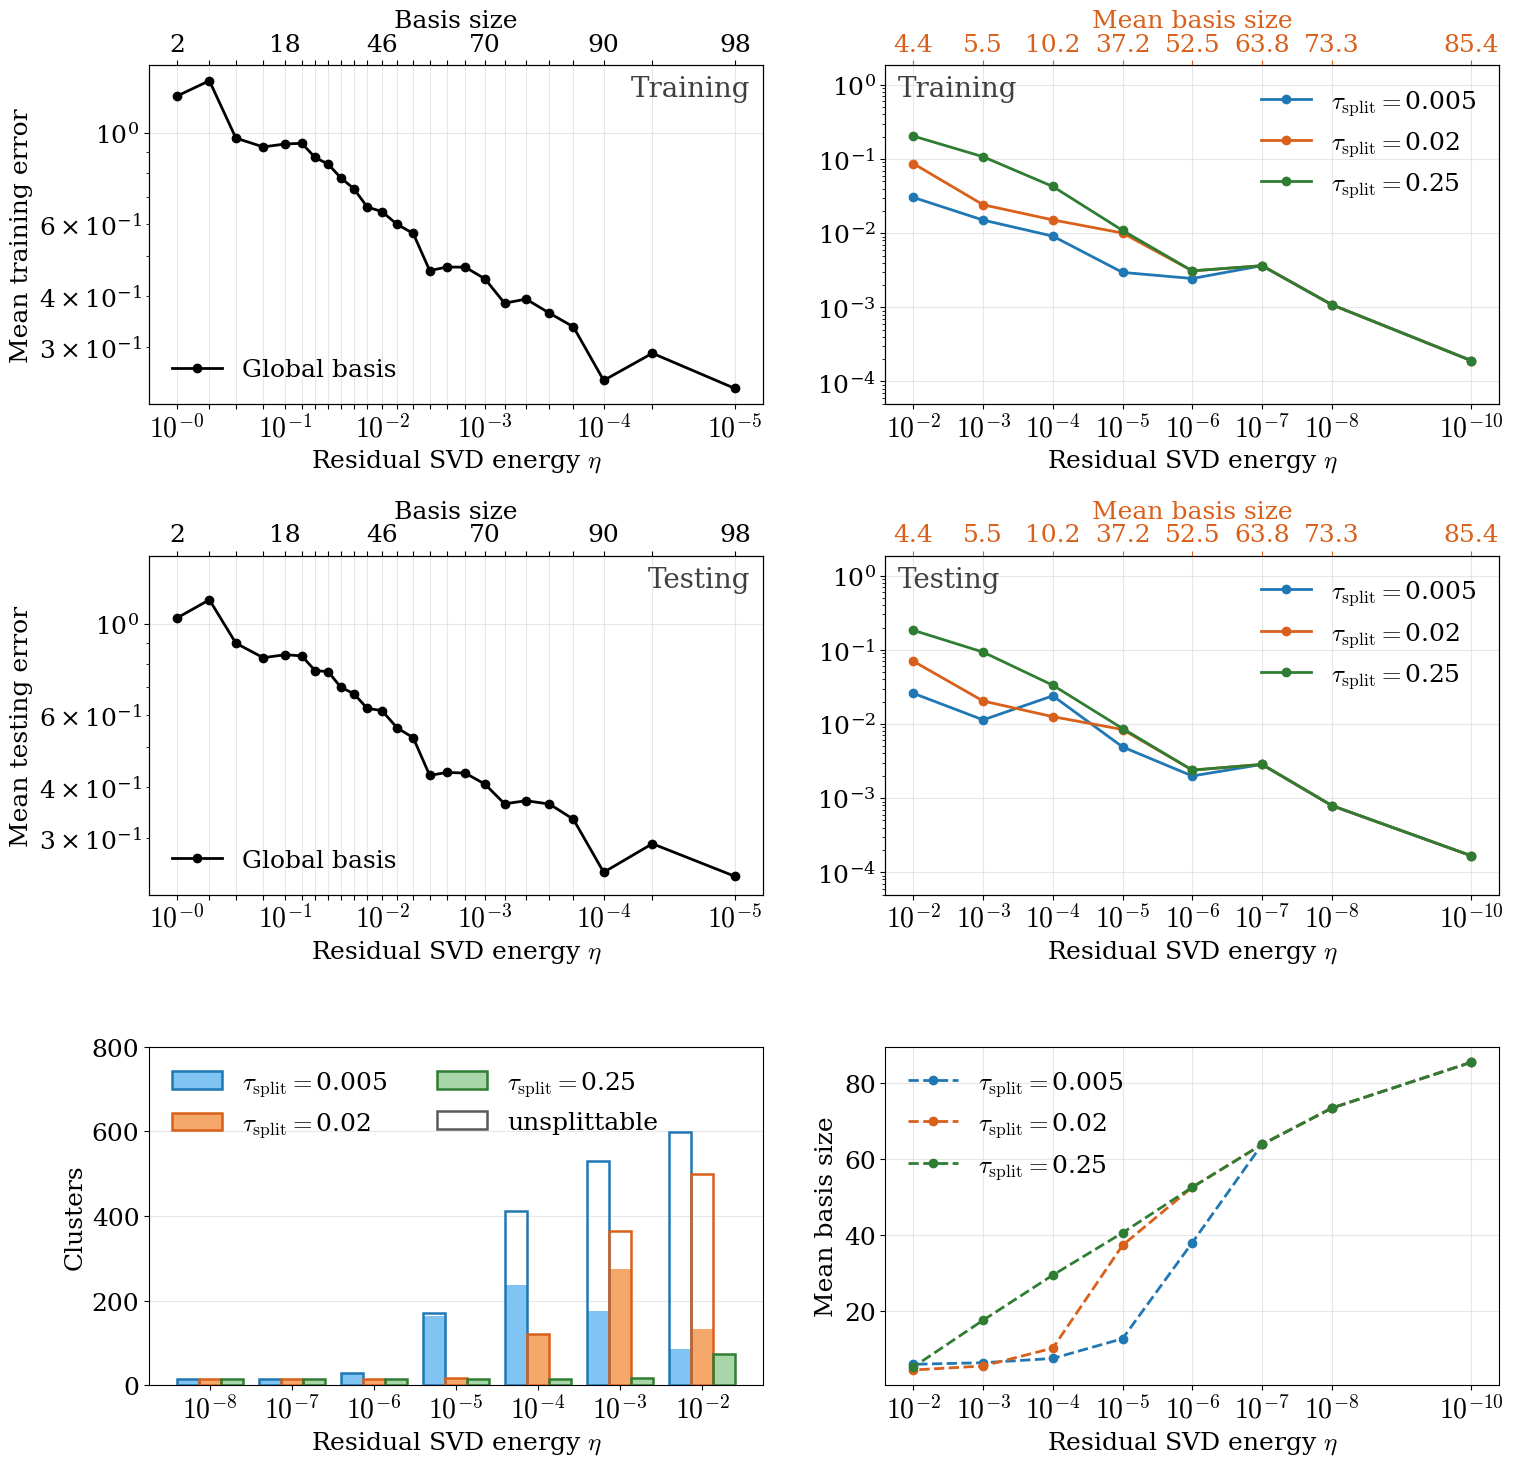

In [6]:
fig, axes = P.sweep_panel_splits(
    sweep_tr, rank_tr, sweep_te, rank_te, qoi,
    show_tols=TOLS,
    twin_tol=TWIN_TOL,
    n_eval_train=N_EVAL["train"],
    n_eval_test=N_EVAL["test"],
    max_clusters=MAX_CLUSTERS,
    agg="l2-in-time",
    ylim=(5e-5, 4e-1),
    max_eta_exp=8,
    bar_headroom=1.9,
    sc_tick_fs=18,
    sc_tick_sep=0.16,
    share_ylim=True,
    caption_headroom=3.0,
    hybrid_train=None,               # no hybrid solver run for Lorenz-96
    hybrid_test=None,
    figsize=(15, 15),
)
ax_sc_tr, ax_cl_tr = axes[0]
ax_sc_te, ax_cl_te = axes[1]
ax_bar, ax_rank = axes[2]


def twin_of(ax):
    """The twin x-axis sharing ``ax``'s position."""
    box = ax.get_position().bounds
    return next(a for a in fig.axes
                if a is not ax and a.get_position().bounds == box)


PANELS = [ax_sc_tr, ax_sc_te, ax_cl_tr, ax_cl_te, ax_bar, ax_rank]
TWINS = [twin_of(a) for a in (ax_sc_tr, ax_sc_te, ax_cl_tr, ax_cl_te)]

ax_sc_tr.set_ylabel("Mean training error")
ax_sc_te.set_ylabel("Mean testing error")
for a in PANELS:
    a.tick_params(axis="x", labelsize=20)
for a in TWINS:
    a.tick_params(axis="x", labelsize=18)

# The axis is rescaled below max_clusters, so the ceiling annotation and its guide line fall outside the axes; text is unclipped by default and would be drawn over the row above.
ax_bar.set_ylim(0, 800)
for txt in list(ax_bar.texts):
    if txt.get_text().startswith("max clusters"):
        txt.remove()
for ln in list(ax_bar.lines):
    if ln.get_linestyle() == ":" and np.allclose(ln.get_ydata(), MAX_CLUSTERS):
        ln.remove()


### One trajectory, banded by cluster

The forcing is constant along a trajectory, so (A, B) and each cluster's reduced
operators are identical at every interval; they are built once per cluster
visited and reused. Each band spans consecutive intervals routed to the same
cluster. The reduced model works in z = x - F, so the curves are shifted back
to x.


Attached ../experiments/lorenz96/N100_F0-2.5/feature_matrix.npy: (460800, 107) (samples/step=6), 150/150 tracers valid
Joint clustering (76,800 steps, 5 params + 4 QoI), k-means k=1 ...
global ROM: one basis over 460,800 snapshots, rank 91 of 100
F = 2.44  |  97 clusters visited, mean rank = 5.85  |  tau_split = 0.02, eta = 0.001


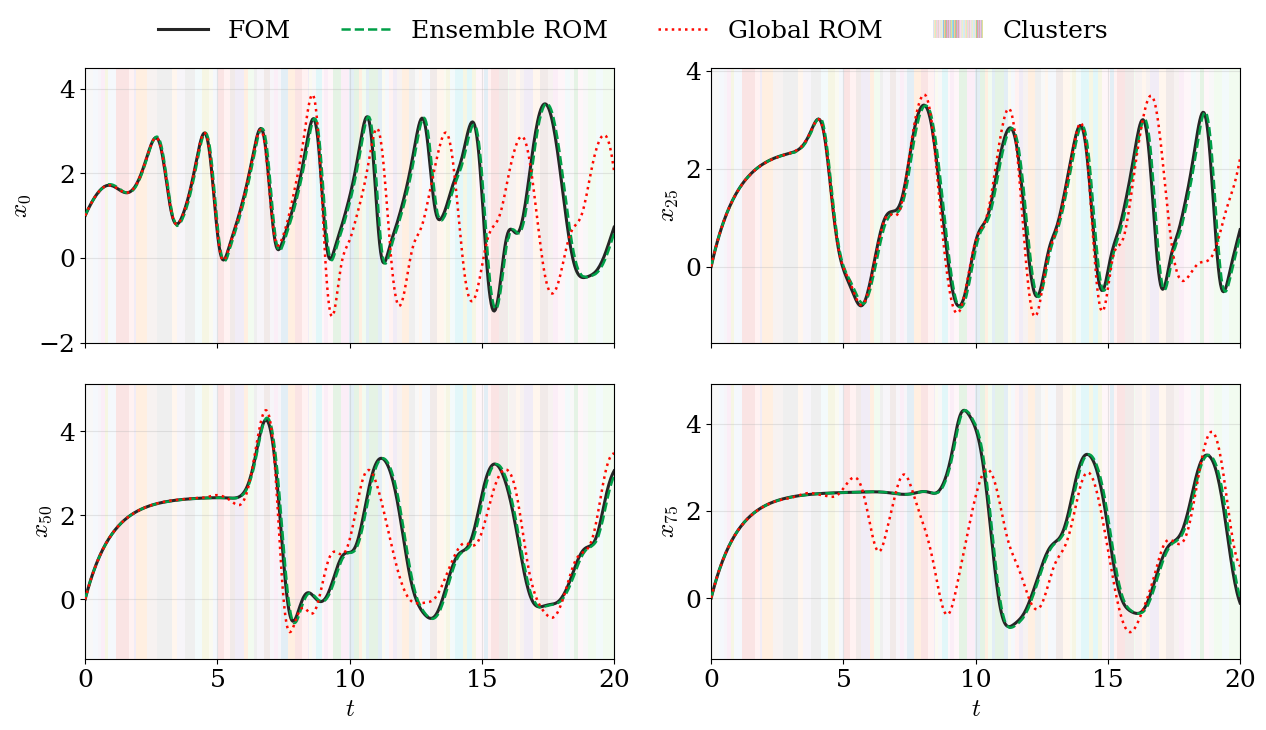

In [7]:
# Shift from z back to x for display.
Fs = np.array([float(np.asarray(tr)[0, 0]) for tr in tracers])
i = int(np.argmin(np.abs(Fs - F_TARGET)))
t_f, y_f, _ = load_trajectories(feat_path, i + 1, ctx.n_species)
pt_i = np.asarray(tracers[i], dtype=np.float64)
F = float(pt_i[0, 0])
knots = ctx.dt_hydro * np.arange(ctx.n_steps + 1)

fm_train = open_feature_matrix(ctx.train_feat_path, len(ctx.train_indices),
                               ctx.n_steps, ctx.n_species)
ens_global = fit_global_rom(fm_train, ctx.net, cfg, ctx.qoi_indices,
                            ctx.param_names, GLOBAL_RANK, cfg.n_workers)

solve = dict(dt_hydro=ctx.dt_hydro, atol=cfg.atol, rtol=cfg.rtol,
             t_eval=knots, positivity=False, method=cfg.ode_method)
z0 = np.asarray(y_f[i])[:, 0]
_, z_rom, route_i, info_rom = ens.solve_tracer(pt_i, z0, **solve)
_, z_glb, _, info_glb = ens_global.solve_tracer(pt_i, z0, **solve)
if info_glb is not None:
    print(f"global ROM failed at F={F:.3g}, rank {GLOBAL_RANK}: {info_glb}")

series = {"reference": np.asarray(y_f[i])[:, ::SUBSTEPS] + F,
          "clustered": None if info_rom is not None else z_rom + F,
          "global": None if info_glb is not None else z_glb + F}

figT, axesT = P.trajectory_panel(knots, series, route_i, QOI)

print(f"F = {F:.3g}  |  {np.unique(route_i).size} clusters visited, "
      f"mean rank = {np.mean([ens.roms[c].basis.rank for c in route_i]):.2f}"
      f"  |  tau_split = {TAU}, eta = {ETA:g}")



### Error against forcing

Per-trajectory error for both datasets against the forcing that produced it, read
from the per-combination CSV files, together with the basis size of every
cluster in the fit.


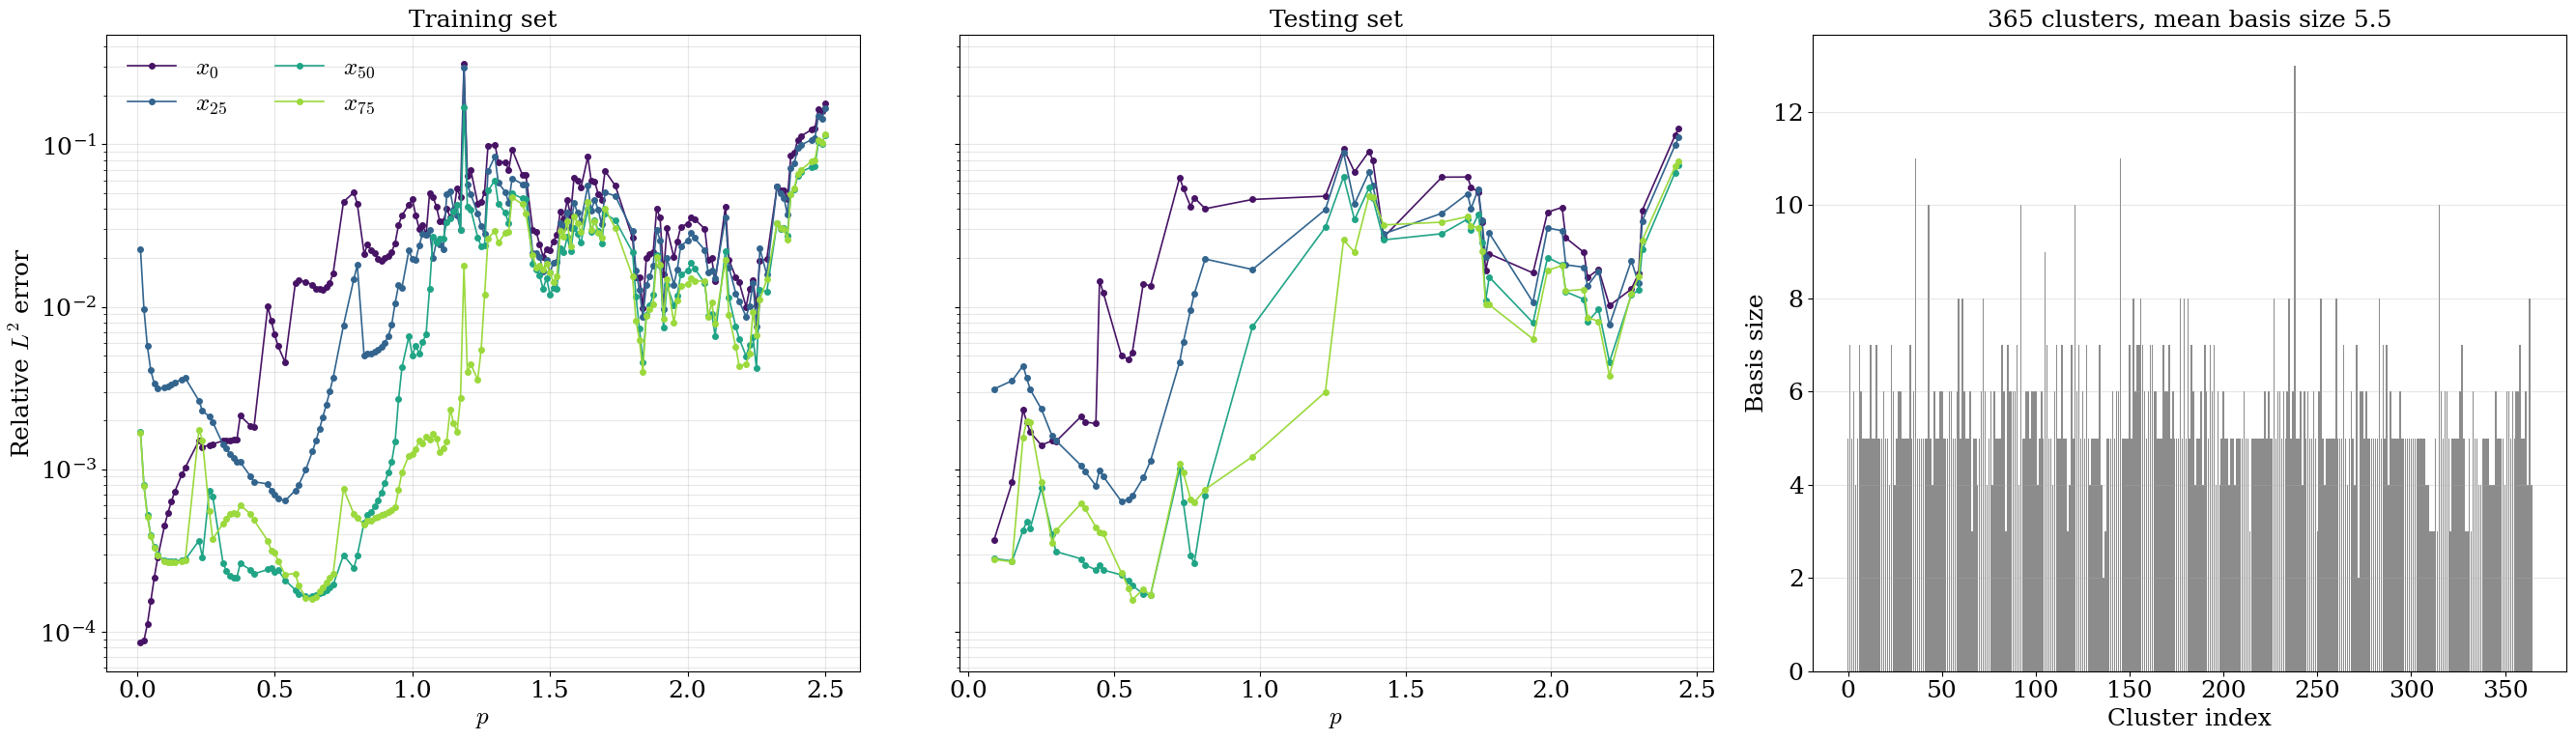

In [8]:
TAGG = "l2-in-time"
F_values = np.load(f"{GEN_DIR}/trajectories_meta.npz")["F_values"]


def per_F(split):
    """Per-trajectory errors for one dataset, ordered by forcing."""
    d = read_table(P.pertracer_path(SWEEP_DIR, TAU, ETA, "off", split))
    Fv = F_values[d["global_id"].astype(int)]
    order = np.argsort(Fv)
    return Fv[order], {q: d[f"{TAGG}|x{q}"][order] for q in QOI}


figE, axesE = P.error_vs_parameter_panel(
    {"training": per_F("train"), "testing": per_F("test")},
    {c: r.basis.rank for c, r in ens.roms.items()},
    QOI, labels=[rf"$x_{{{q}}}$" for q in QOI], agg=TAGG)




## Save


In [9]:
os.makedirs(FIG_DIR, exist_ok=True)

fig.savefig(f"{FIG_DIR}/lorenz96_fullstate_panel.pdf", dpi=200,
            bbox_inches="tight")
figT.savefig(f"{FIG_DIR}/lorenz_abundance.pdf", dpi=200)
figE.savefig(f"{FIG_DIR}/err_vs_F.pdf", dpi=200)